In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("train.csv").set_index("gameId")
df

,blueWins,blueWardsPlaced,blueWardsDestroyed,blueFirstBlood,blueKills,blueDeaths,blueAssists,blueEliteMonsters,blueDragons,blueHeralds,...,redTowersDestroyed,redTotalGold,redAvgLevel,redTotalExperience,redTotalMinionsKilled,redTotalJungleMinionsKilled,redGoldDiff,redExperienceDiff,redCSPerMin,redGoldPerMin
gameId,,,,,,,,,,,,,,,,,,,,,
4514193601,1,11,3,0,7,3,7,0,0,0,...,0,14990,6.6,17067,225,45,-1474,-963,22.5,1499.0
4503065497,0,91,3,1,6,1,4,2,1,1,...,0,13750,6.8,17900,218,56,-3266,-1337,21.8,1375.0
4447986050,1,20,6,1,11,8,12,1,1,0,...,0,16904,6.8,17866,194,48,-2445,-1807,19.4,1690.4
4520976634,0,16,2,1,2,11,2,1,1,0,...,1,19472,7.2,19342,245,40,5540,3682,24.5,1947.2
4449282228,1,12,4,0,5,4,7,1,1,0,...,0,14885,6.6,16805,197,44,-1603,-1827,19.7,1488.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4521085954,0,12,1,0,6,7,8,0,0,0,...,1,18285,7.0,18855,193,59,2025,1774,19.3,1828.5
4523056314,1,15,3,1,10,8,8,1,1,0,...,0,16643,6.8,16938,196,45,-975,-1131,19.6,1664.3
4519092330,0,15,1,0,1,3,1,0,0,0,...,0,15604,7.0,18482,241,48,1661,1064,24.1,1560.4


<Axes: xlabel='blueDeaths', ylabel='redAvgLevel'>

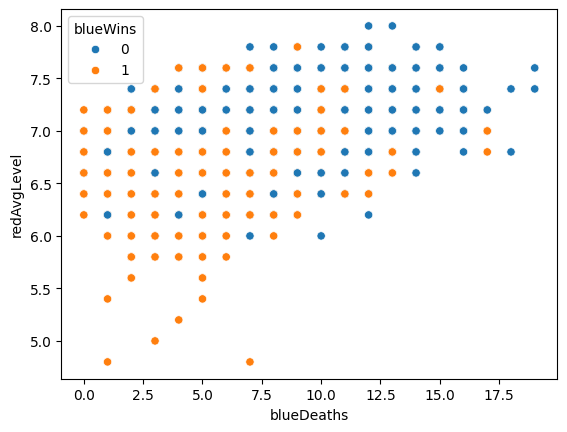

In [8]:
sns.scatterplot(data=df, x="blueDeaths", y="redAvgLevel", hue="blueWins")

In [16]:
xall, yall = df.iloc[:, 1:].to_numpy(), df.iloc[:, 0].to_numpy()

In [351]:
from sklearn.model_selection import train_test_split

x, xt, y, yt = train_test_split(xall, yall, test_size=0.2, random_state=67, stratify=yall)
print(x.shape)
print(y.shape)

(6322, 38)
(6322,)


In [311]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, PowerTransformer
from sklearn.feature_selection import SelectKBest, VarianceThreshold, f_classif
from sklearn.ensemble import IsolationForest
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression

model = make_pipeline(
    # LGBMClassifier(random_state=67)
    # CatBoostClassifier(random_state=67)
    StandardScaler(),
    PowerTransformer(),
    PolynomialFeatures(degree=2),
    VarianceThreshold(),
    SelectKBest(score_func=f_classif, k=20),
    LogisticRegression(random_state=67, C=0.1)
)
model.fit(x, y)

predt = model.predict_proba(xt)[:, 1] >= 0.3
# predt = model.predict(xt)

In [312]:
from sklearn.metrics import f1_score

print(f1_score(yt, predt))

0.7375


In [313]:
dfsub = pd.read_csv("test.csv").set_index("gameId")
xsub = dfsub.to_numpy()
predsub = model.predict_proba(xsub)[:, 1] >= 0.3

pd.Series(predsub, name="blueWins", index=dfsub.index).to_csv("submission.csv")

## versi m.o.e

In [366]:
from sklearn.cluster import KMeans

clusnum = 2

kmeans = KMeans(n_clusters=clusnum, random_state=67)
clusters = kmeans.fit_predict(x)

In [367]:
models = []

for i in range(clusnum):
    xi = x[clusters == i]
    yi = y[clusters == i]

    m = make_pipeline(
        StandardScaler(),
        PowerTransformer(),
        PolynomialFeatures(degree=2),
        VarianceThreshold(),
        SelectKBest(score_func=f_classif, k=20),
        LogisticRegression(random_state=67, C=1)
    )
    
    m.fit(xi, yi)
    models.append(m)

In [368]:
cluster_test = kmeans.predict(xt)

proba = np.zeros(len(xt))

for i in range(clusnum):
    mask = cluster_test == i
    proba[mask] = models[i].predict_proba(xt[mask])[:, 1]

predt = (proba >= 0.3).astype(int)
print(f1_score(yt, predt))

0.7462061747776033


In [369]:
cluster_sub = kmeans.predict(xsub)

proba_sub = np.zeros(len(xsub))

for i in range(clusnum):
    mask = cluster_sub == i
    proba_sub[mask] = models[i].predict_proba(xsub[mask])[:, 1]

predsub = (proba_sub >= 0.3).astype(int)
pd.Series(predsub, name="blueWins", index=dfsub.index).to_csv("submission.csv")